In [1]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cmocean as cm


In [2]:

#data_dir = '/Users/zoecas/Documents/data/'
#filename = 'SWOT_L2_LR_SSH_Basic_045_216_20260131T225821_20260131T234949_PID0_01.nc'

if True:
    data_dir = Path('/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409')
    files = list(data_dir.glob('SWOT_L2_LR_SSH_*.nc'))
    print(f'Found {len(list(files))} files')

Found 511 files


In [6]:
files[0]

PosixPath('/Users/zoecas/Documents/data/SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/SWOT_L2_LR_SSH_Basic_044_098_20260106T210232_20260106T215400_PID0_01.nc')

In [3]:
datasets = [xr.open_dataset(f) for f in files[:50]]

In [4]:
datasets = [d.where(np.abs(d.ssha_karin)<2.5) for d in datasets]

In [5]:
_ds = xr.concat(datasets, dim='num_lines')

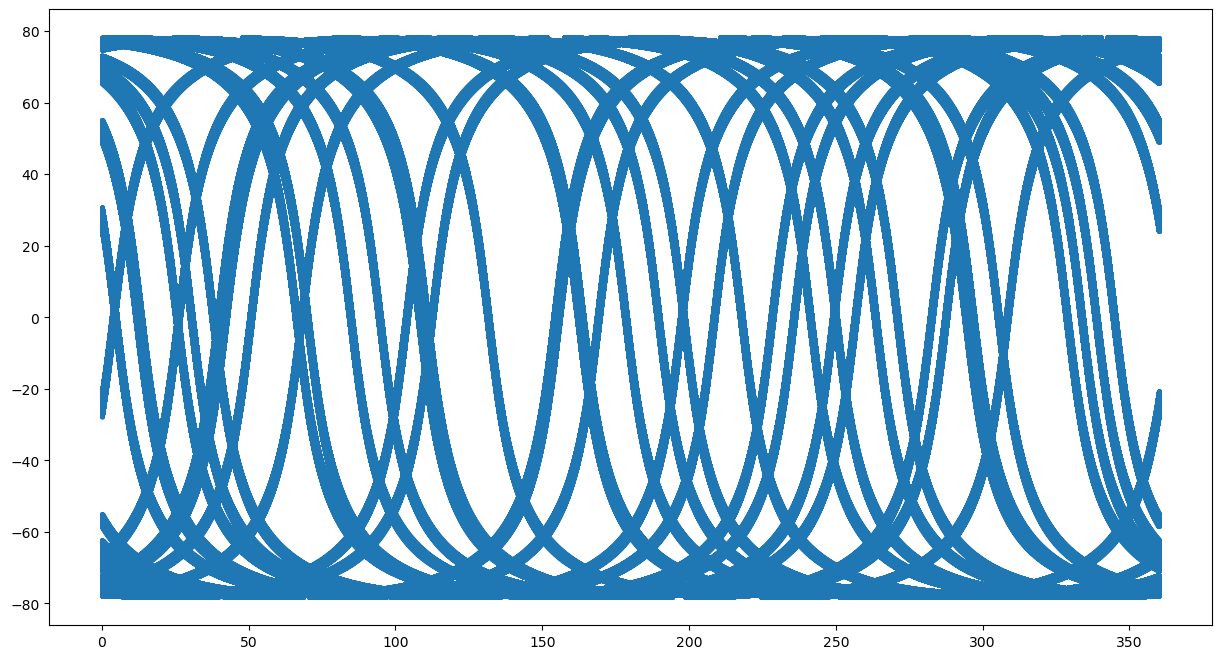

In [15]:
plt.figure(figsize=(15,8))
plt.scatter((_ds.longitude.values),(_ds.latitude.values),s=5)

In [68]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_segments(lon,lat,dat,title,vmin,vmax):
    proj = ccrs.PlateCarree()
    extent = [np.nanmin(lon),
              np.nanmax(lon),
              np.nanmin(lat),
              np.nanmax(lat)]
    
    # Add the scatter plot
    lon=lon.flatten()
    lat=lat.flatten()
    
    fig = plt.figure(figsize=(10,10))
    ax = plt.axes(projection=proj)
    
    im=ax.scatter(lon, lat, c=dat, s=1, cmap=plt.cm.bwr,
                  transform=ccrs.PlateCarree(),
                  vmin=vmin,vmax=vmax )
    # Add the colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', 
                        pad=0.02, aspect=40, shrink=0.8,
                        extend='both' , label='meter')
    ax.coastlines(resolution='10m')
    #ax.add_feature(cfeature.LAND, color='lightgrey')
    #ax.add_feature(cfeature.OCEAN, color='lightblue')
    #ax.add_feature(cfeature.RIVERS)
    gl=ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = gl.right_labels = False
    ax.set_extent(extent, proj)
    ax.set_title(title)
    return ax

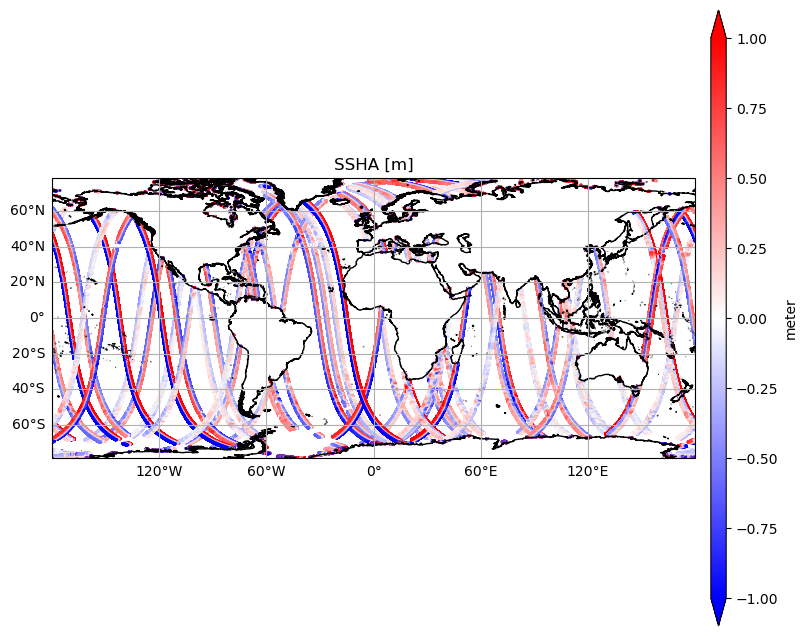

In [42]:

title = 'SSHA [m]'
lon = _ds.longitude.values
lat = _ds.latitude.values
dat = _ds.ssha_karin.values

vmin, vmax = -1,1
plot_segments(lon,lat,dat,title,vmin,vmax)

Notes: Concatenation seems straightforward though computationaly heavy => set up parallelized computation

In [31]:
# Tests with 1 file
test = datasets[0]
test

<xarray.Dataset> Size: 128MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines, num_pixels) datetime64[ns] 5MB ...
    time_tai                               (num_lines, num_pixels) datetime64[ns] 5MB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

(-20.0, 34.100217999999984)

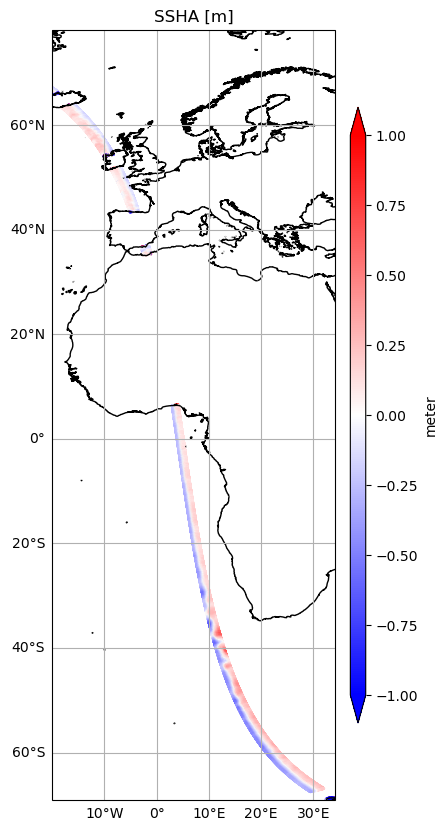

In [73]:
title = 'SSHA [m]'
lon = test.longitude.where(np.isnan(dat)==False).values
lat = test.latitude.where(np.isnan(dat)==False).values
dat = test.ssha_karin.where(np.isnan(dat)==False).values
vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,lonmax)

(-60.0, -40.0)

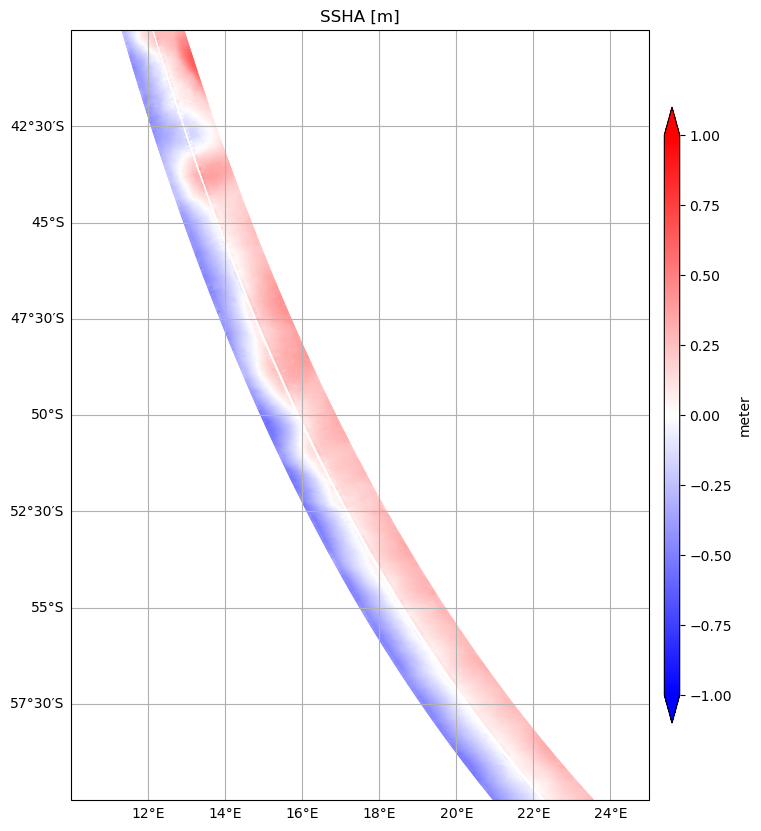

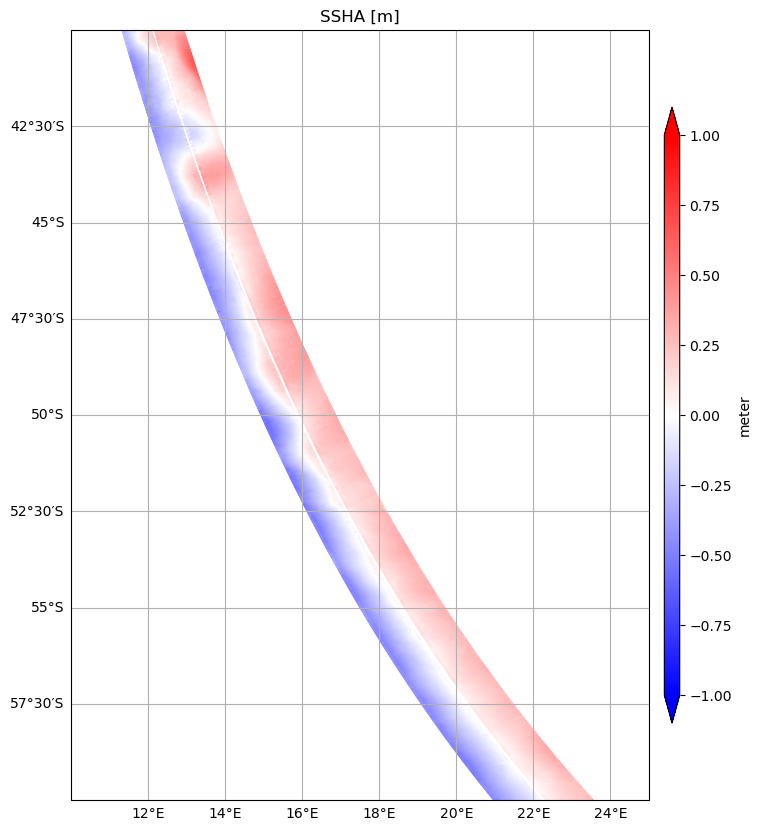

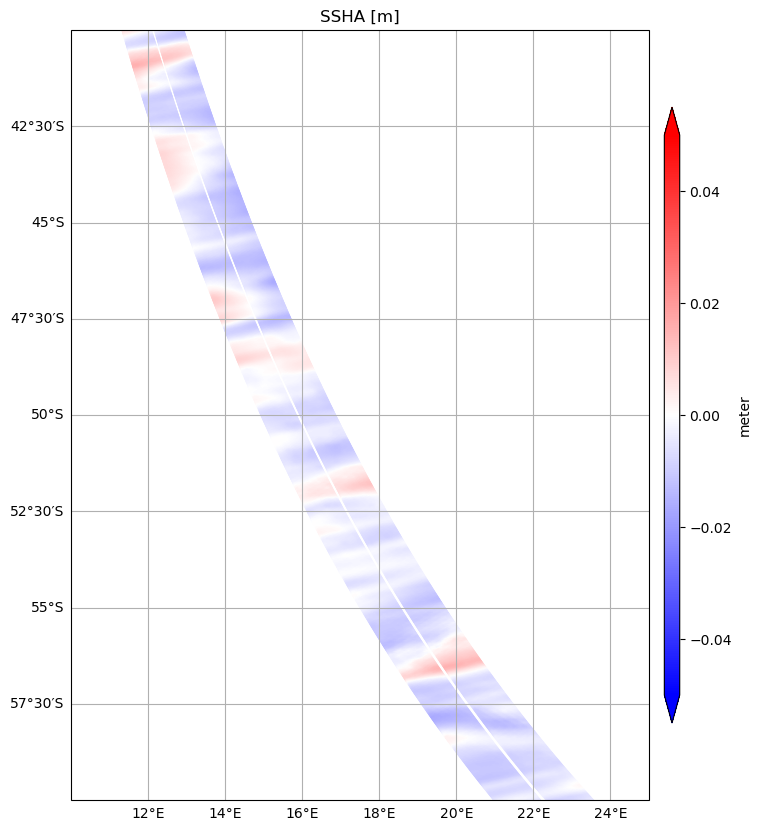

In [97]:
title = 'SSHA [m]'
lon = test.longitude.values
lat = test.latitude.values
dat = test.ssha_karin.values
vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)


dat = test.ssha_karin_2.values


vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -1,1

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,-0.05,0.05)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

(-60.0, -40.0)

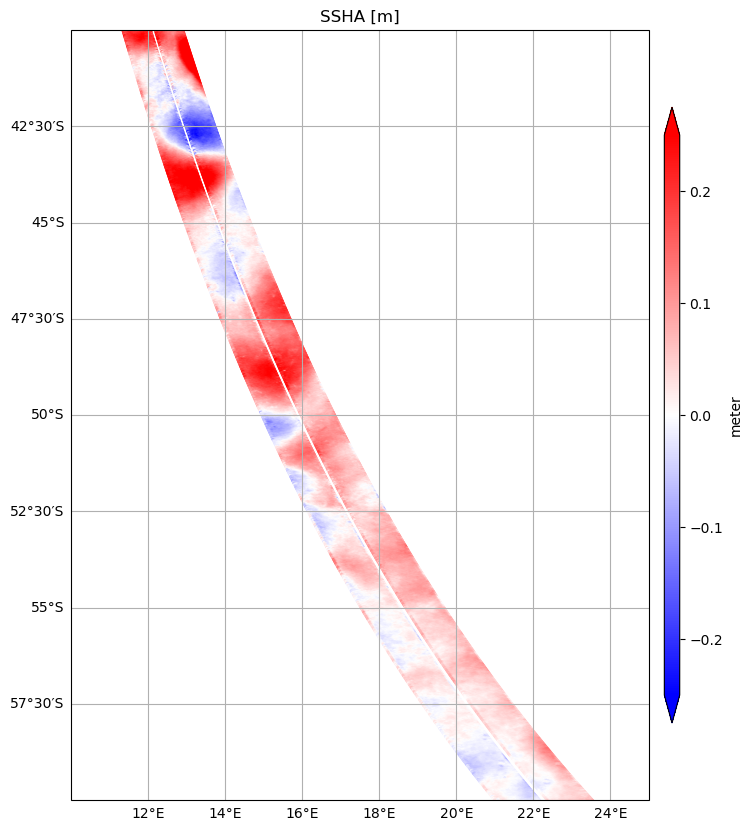

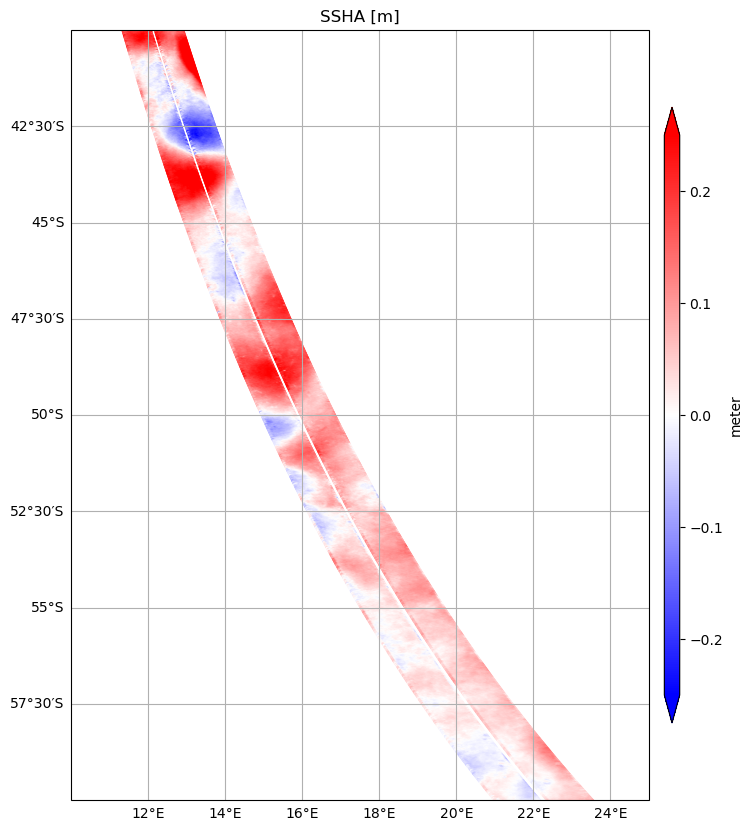

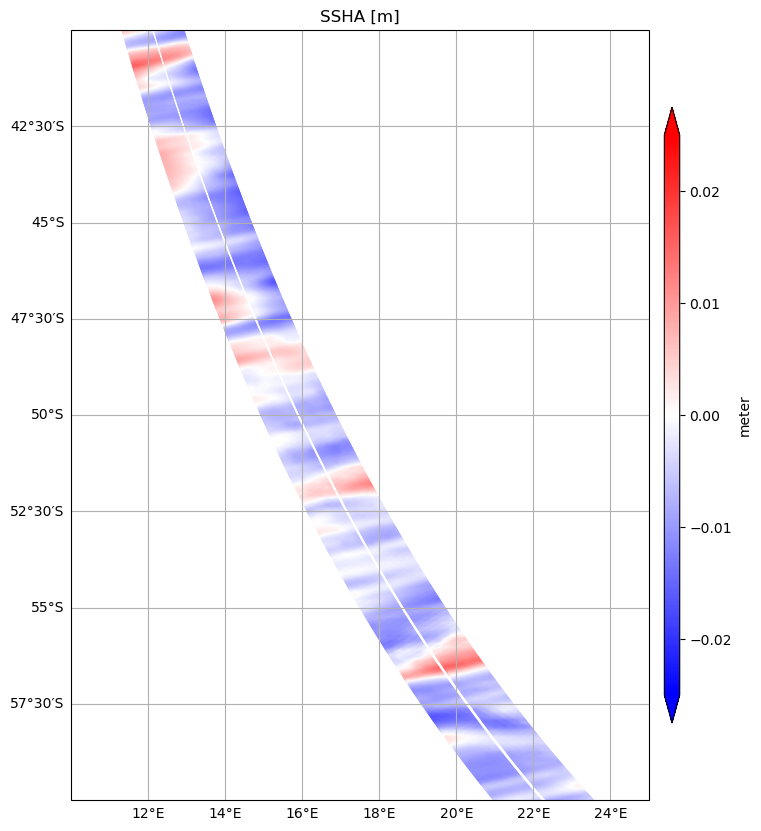

In [99]:
dat = (test.ssha_karin + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(10,25)
ax.set_ylim(-60,-40)

(50.0, 65.0)

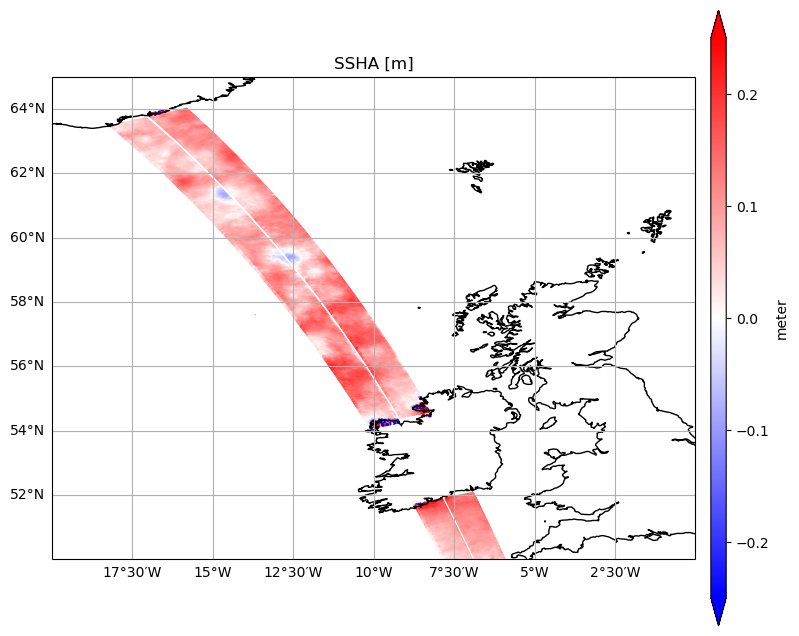

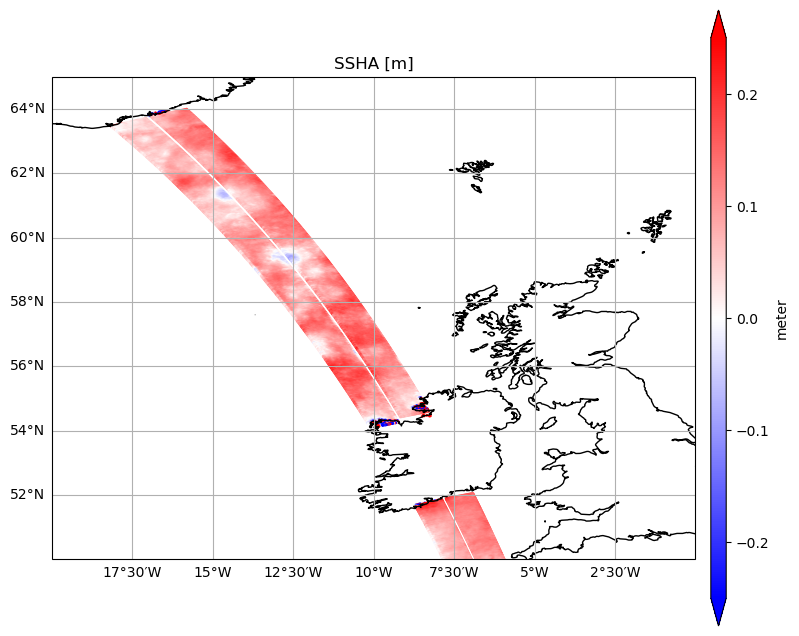

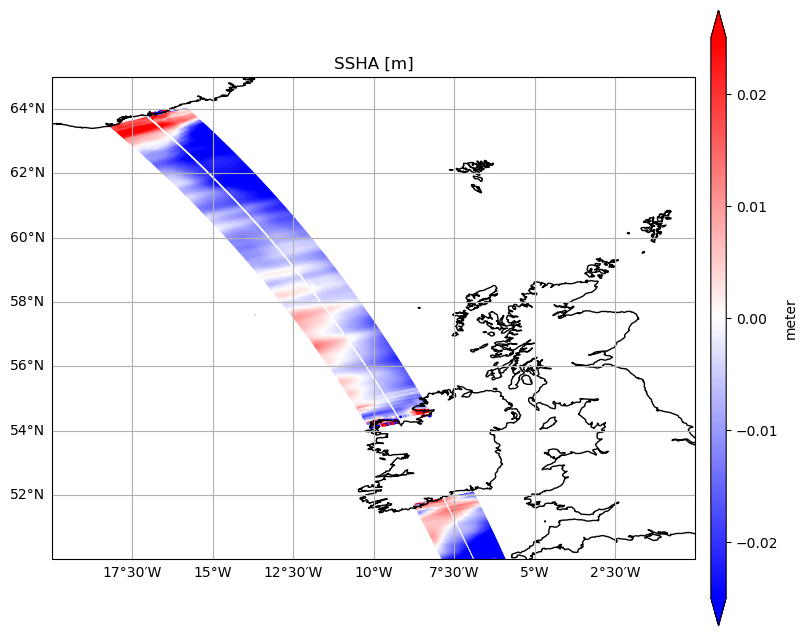

In [100]:
dat = (test.ssha_karin + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin_2 + test.height_cor_xover).values

vmin, vmax = -0.25,0.25

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

dat = (test.ssha_karin-test.ssha_karin_2).values

vmin, vmax = -0.025,0.025

lonmax = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((test.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(-20,0)
ax.set_ylim(50,65)

In [85]:
dat = (test.ssha_karin-test.height_cor_xover)

<xarray.DataArray (num_lines: 9866, num_pixels: 69)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(9866, 69))
Coordinates:
    latitude   (num_lines, num_pixels) float64 5MB 78.27 78.25 ... -78.25 -78.27
    longitude  (num_lines, num_pixels) float64 5MB 280.8 280.8 ... 88.23 88.23
Dimensions without coordinates: num_lines, num_pixels
Attributes:
    units:    m

In [ ]:
# Bias correction (optional)
ssha_1 = swot.fit_bias(
        ssha, distance,
        check_bad_point_threshold=0.1,
        remove_along_track_polynomial=True
    )